In [7]:
import networkx as nx
import pickle
import copy
import matplotlib.pyplot as plt
from epidemic_simulation.sir_simulation import fast_SIR
from epidemic_simulation.helpers import *
from sample.helpers import *
from sample.sampling_trees_MH import TreeSamplerMH
from sample.sampling_trees import feasible_tree

In [8]:
#Loading our example of verification test
n = 20
p = 5/(n - 1)
G = nx.erdos_renyi_graph(n, p)

beta = 0.4
fast_SIR(G, [0], beta)

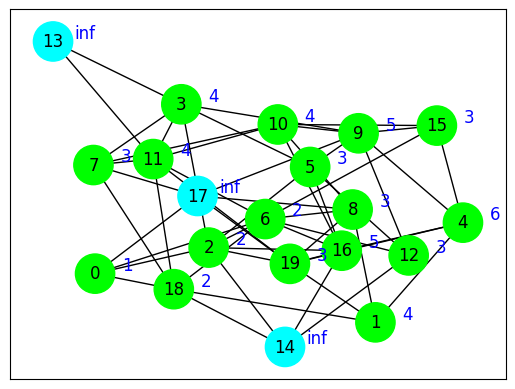

In [9]:
#Visualization of the graph with their respectives infection times
color_state_map = {'recovered': 'lime', 'susceptible': 'cyan'}
node_color = [color_state_map[node[1]['status']] for node in G.nodes(data=True)]

infection_times = nx.get_node_attributes(G, "inf_time")
pos = nx.spring_layout(G, seed = 0)
state_pos = {n: (x + 0.14, y + 0.05) for n, (x,y) in pos.items()}

nx.draw_networkx(G,
                pos,
                node_size = 800,
                node_color = node_color,)

nx.draw_networkx_labels(G, state_pos, labels= infection_times, font_color='blue')
plt.show()

In [10]:
#Making a copy with the real infection times
G_real = copy.deepcopy(G)

#Selecting a fraction of nodes that will not be observed.
p_excluded = 0.4
excluded, infected_nodes = excludeInfTime(G, p_excluded)

#Deleting nodes that we known were not infected from the graph.
delete_susceptibles(G)

T_initial = feasible_tree(G, infected_nodes, flag=1)

In [ ]:
if None in T_initial:
    print("Feasible tree not found!")

else:
    print(T_initial)

    samplings_number = 1000

    #Initialize class
    sampler = TreeSamplerMH(G, T_initial, infected_nodes,flag=1)

    #Run
    sampling = sampler.run(n_iterations=samplings_number)
    print(f"Real infection times: {nx.get_node_attributes(G_real, "inf_time")}")
    print("--------------------------------------------------------------------------------------------")
    print(f"Frequency of nodes: {nodes_proportion(G, sampling)}")

[[0], [2, 0], [5, 2], [6, 0], [9, 4, 19], [10, 16, 6], [11, 19], [15, 6], [18, 0], [19, 2]]


Sampling trees:  11%|█         | 11/100 [00:00<00:00, 104.73it/s]

0.15443745413852455
Succes events: 11
Failed events: 17
-23.399430366579
0.15443745413852455
Succes events: 12
Failed events: 17
-25.267396458770513
0.15443745413852455
Succes events: 11
Failed events: 17
-23.399430366579
log-likelihood: -23.399430366579 
0.15443745413852455
Succes events: 12
Failed events: 17
-25.267396458770513
0.593724825776194
Succes events: 12
Failed events: 17
-21.568389737643443
0.593724825776194
Succes events: 12
Failed events: 17
-21.568389737643443
0.593724825776194
Succes events: 12
Failed events: 17
-21.568389737643443
log-likelihood: -21.568389737643443 
0.593724825776194
Succes events: 12
Failed events: 17
-21.568389737643443
0.6881915249766751
Succes events: 12
Failed events: 17
-24.295481615604523
0.6881915249766751
Succes events: 11
Failed events: 17
-23.921793515141953
0.6881915249766751
Succes events: 12
Failed events: 17
-24.295481615604523
log-likelihood: -24.295481615604523 
0.3740073013674998
Succes events: 12
Failed events: 17
-19.76484122772110

Sampling trees:  22%|██▏       | 22/100 [00:00<00:00, 106.71it/s]

0.02783944454416697
Succes events: 14
Failed events: 9
-50.39232830493477
0.6458003763021424
Succes events: 14
Failed events: 9
-15.46275927584076
0.6458003763021424
Succes events: 14
Failed events: 9
-15.46275927584076
0.6458003763021424
Succes events: 14
Failed events: 9
-15.46275927584076
log-likelihood: -15.46275927584076 
0.6458003763021424
Succes events: 14
Failed events: 9
-15.46275927584076
0.5599428338163261
Succes events: 14
Failed events: 9
-15.506543897363397
0.5599428338163261
Succes events: 14
Failed events: 9
-15.506543897363397
0.5599428338163261
Succes events: 14
Failed events: 9
-15.506543897363397
log-likelihood: -15.506543897363397 
0.5599428338163261
Succes events: 14
Failed events: 9
-15.506543897363397
0.6113760268915963
Succes events: 14
Failed events: 9
-15.394890603540887
0.6113760268915963
Succes events: 14
Failed events: 9
-15.394890603540887
0.6113760268915963
Succes events: 14
Failed events: 9
-15.394890603540887
log-likelihood: -15.394890603540887 
0.6113

...

0.6466823628171076
Succes events: 17
Failed events: 0
-7.410300739327514
0.6466823628171076
Succes events: 17
Failed events: 0
-7.410300739327514
0.6466823628171076
Succes events: 17
Failed events: 0
-7.410300739327514
log-likelihood: -7.410300739327514 
0.6466823628171076
Succes events: 17
Failed events: 0
-7.410300739327514
0.3787151132555453
Succes events: 17
Failed events: 0
-16.506507622494894
0.3787151132555453
Succes events: 16
Failed events: 4
-17.439398775567515
0.3787151132555453
Succes events: 17
Failed events: 0
-16.506507622494894
log-likelihood: -16.506507622494894 
0.5509829954526817
Succes events: 17
Failed events: 0
-10.13287263639832
0.5509829954526817
Succes events: 16
Failed events: 2
-11.138210344673448
0.5509829954526817
Succes events: 17
Failed events: 0
-10.13287263639832
log-likelihood: -10.13287263639832 
0.5748951641759688
Succes events: 17
Failed events: 0
-9.410648825658384
0.5748951641759688
Succes events: 16
Failed events: 2
-10.567920183576987
0.57489516

Sampling trees:  91%|█████████ | 91/100 [00:00<00:00, 108.87it/s]

0.7406707095601783
Succes events: 17
Failed events: 0
-5.103385363229207
0.7406707095601783
Succes events: 17
Failed events: 0
-5.103385363229207
0.7406707095601783
Succes events: 17
Failed events: 0
-5.103385363229207
log-likelihood: -5.103385363229207 
0.7406707095601783
Succes events: 17
Failed events: 0
-5.103385363229207
0.8278054053478374
Succes events: 17
Failed events: 0
-3.2126118885331088
0.8278054053478374
Succes events: 17
Failed events: 0
-3.2126118885331088
0.8278054053478374
Succes events: 17
Failed events: 0
-3.2126118885331088
log-likelihood: -3.2126118885331088 
0.8278054053478374
Succes events: 17
Failed events: 0
-3.2126118885331088
0.4680095714677599
Succes events: 17
Failed events: 0
-12.907531034130459
0.4680095714677599
Succes events: 16
Failed events: 2
-13.410524065277206
0.4680095714677599
Succes events: 17
Failed events: 0
-12.907531034130459
log-likelihood: -12.907531034130459 
0.6651495052705307
Succes events: 17
Failed events: 0
-6.931638541859884
0.66514

Sampling trees: 100%|██████████| 100/100 [00:00<00:00, 103.70it/s]


log-likelihood: -6.790873943310474 
0.4433914624768413
Succes events: 17
Failed events: 0
-13.826138023235202
0.4433914624768413
Succes events: 17
Failed events: 0
-13.826138023235202
0.4433914624768413
Succes events: 17
Failed events: 0
-13.826138023235202
log-likelihood: -13.826138023235202 
0.36315770466348274
Succes events: 17
Failed events: 0
-17.219607546214153
0.36315770466348274
Succes events: 17
Failed events: 0
-17.219607546214153
0.36315770466348274
Succes events: 17
Failed events: 0
-17.219607546214153
log-likelihood: -17.219607546214153 
0.36315770466348274
Succes events: 17
Failed events: 0
-17.219607546214153
0.7518059661957484
Succes events: 17
Failed events: 0
-4.849709204033994
0.6713760838758339
Succes events: 17
Failed events: 0
-6.773238877879457
0.5831311453107202
Succes events: 17
Failed events: 0
-9.168833870516341
0.5831311453107202
Succes events: 17
Failed events: 0
-9.168833870516341
0.5831311453107202
Succes events: 17
Failed events: 0
-9.168833870516341
log

### Plots (visualizing results)
Trace plot

(The drops to low values (e.g., -40) is an indicator of bugs or an instability in the acceptance logic)

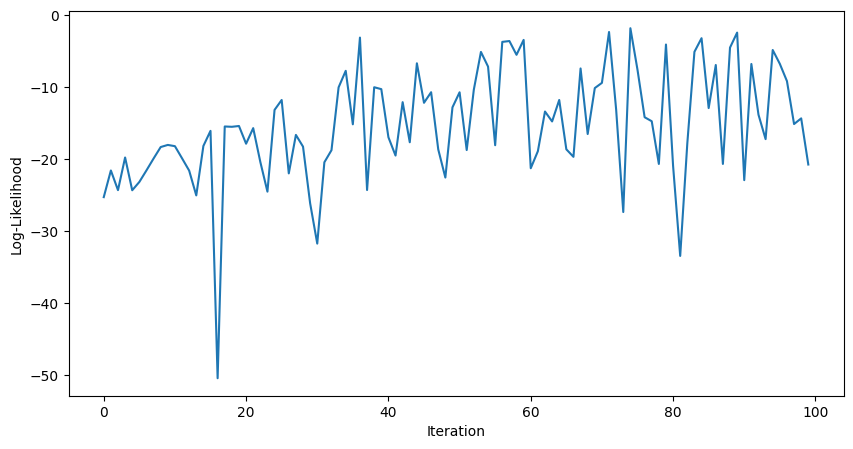

In [12]:
sampler._trace_plot_log_likelihood()